# **Machine Learning-Based Network Intrusion Detection System**

---


LIBRARIES

In [1]:
!pip install datasets

LOAD DATASET DIRECTLY

In [2]:
from datasets import load_dataset

dataset = load_dataset("c01dsnap/CIC-IDS2017")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/771 [00:00<?, ?B/s]

Friday-WorkingHours-Afternoon-DDos.pcap_(…):   0%|          | 0.00/77.1M [00:00<?, ?B/s]

Friday-WorkingHours-Afternoon-PortScan.p(…):   0%|          | 0.00/76.9M [00:00<?, ?B/s]

Friday-WorkingHours-Morning.pcap_ISCX.cs(…):   0%|          | 0.00/58.3M [00:00<?, ?B/s]

...

Thursday-WorkingHours-Afternoon-Infilter(…):   0%|          | 0.00/83.1M [00:00<?, ?B/s]

Thursday-WorkingHours-Morning-WebAttacks(…):   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Tuesday-WorkingHours.pcap_ISCX.csv:   0%|          | 0.00/135M [00:00<?, ?B/s]

Wednesday-workingHours.pcap_ISCX.csv:   0%|          | 0.00/225M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2830743 [00:00<?, ? examples/s]

CONVERTING TO PANDAS

In [3]:
df = dataset['train'].to_pandas()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


LOAD ONLY 20% OF DATA

In [4]:
dataset = load_dataset("c01dsnap/CIC-IDS2017", split="train[:20%]")
df = dataset.to_pandas()

CHECK TARGET COLUMN

In [5]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

CHECK CLASS DISTRIBUTION

In [6]:
df[' Label'].value_counts()

,count
Label,
BENIGN,279190
PortScan,158930
DDoS,128027
Bot,2


BINARY CONVERSION

In [7]:
df[' Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

df[' Label'].value_counts()

,count
Label,
1,286959
0,279190


DATA TYPES

In [8]:
df.dtypes

,0
Destination Port,int64
Flow Duration,int64
Total Fwd Packets,int64
Total Backward Packets,int64
Total Length of Fwd Packets,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,int64
Idle Min,int64


REMOVE NON-NUMERIC COLUMNS

In [9]:
df = df.select_dtypes(include=['int64', 'float64'])

print("New Shape:", df.shape)

New Shape: (566149, 79)


HANDLING MISSING / INFINITE VALUES

In [10]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("After cleaning:", df.shape)

After cleaning: (565695, 79)


SPLIT FEATURES AND LABELS

In [11]:
X = df.drop(' Label', axis=1)
y = df[' Label']

TRAIN - TEST SPLIT

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (452556, 78)
Test Shape: (113139, 78)


RANDOM FOREST MODEL

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=20,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Training Completed ✅")

Model Training Completed ✅


MODEL EVALUATION

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9983383271904471

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55642
           1       1.00      1.00      1.00     57497

    accuracy                           1.00    113139
   macro avg       1.00      1.00      1.00    113139
weighted avg       1.00      1.00      1.00    113139



CONFUSION MATRIX

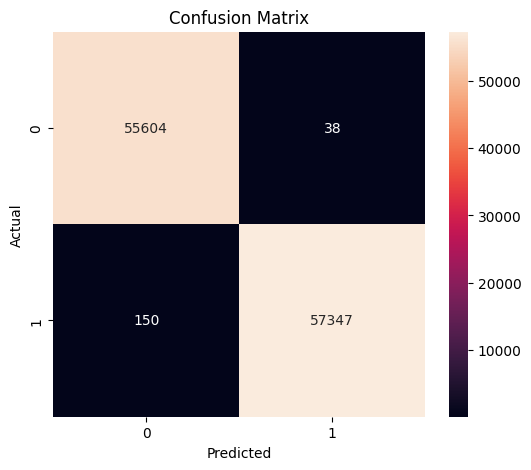

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

COMPARING MULTIPLE MODELS

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    "RandomForest": RandomForestClassifier(n_estimators=20, max_depth=5, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))


RandomForest
Accuracy: 0.998647681170949

DecisionTree
Accuracy: 0.9829766923872405

LogisticRegression
Accuracy: 0.917932808315435


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


FEATURE IMPORTANCE(Adds Intelligence)

In [17]:
rf = RandomForestClassifier(n_estimators=20, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

 Fwd Packet Length Max         0.138998
Init_Win_bytes_forward         0.104500
 Avg Fwd Segment Size          0.067343
Total Length of Fwd Packets    0.059492
 Fwd Header Length             0.044045
 Destination Port              0.035914
 ACK Flag Count                0.033144
 Min Packet Length             0.032424
 Fwd Header Length.1           0.031701
 Subflow Fwd Bytes             0.030308
dtype: float64


MODEL SAVING

In [18]:
import joblib

joblib.dump(rf, "nids_model.pkl")
print("Model Saved Successfully ✅")

Model Saved Successfully ✅


FEATURE SCALING

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ADD XGBOOST

In [20]:
!pip install xgboost

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:05:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9995403883718258


MULTI-CLASS CLASSIFICATION

In [22]:
df[' Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df[' Label'] = le.fit_transform(df[' Label'])

SAVE MODEL

In [24]:
import joblib

joblib.dump(xgb, "nids_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler Saved ✅")

Model and Scaler Saved ✅


REAL-TIME SIMULATION

In [25]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)

prediction = xgb.predict(sample_scaled)

if prediction[0] == 0:
    print("Predicted Class: BENIGN")
else:
    print("Predicted Class: ATTACK")

Predicted Class: ATTACK


LIBRARIES

In [26]:
!pip install flask flask-ngrok pyngrok

FLASK APP FILE

In [27]:
%%writefile app.py
from flask import Flask, request, render_template_string
import joblib
import numpy as np
import pandas as pd

app = Flask(__name__)

# Load model and scaler
model = joblib.load("nids_model.pkl")
scaler = joblib.load("scaler.pkl")

# Simple HTML template
html_template = """
<!doctype html>
<title>NIDS Dashboard</title>
<h2>AI Network Intrusion Detection System</h2>
<form method="post">
  <label>Enter feature values (comma separated):</label><br><br>
  <input type="text" name="features" size="100"><br><br>
  <input type="submit" value="Predict">
</form>

{% if prediction %}
<h3>Prediction: {{ prediction }}</h3>
<h4>Attack Probability: {{ probability }}</h4>
{% endif %}
"""

@app.route("/", methods=["GET", "POST"])
def home():
    if request.method == "POST":
        try:
            features = request.form["features"]
            feature_list = [float(x) for x in features.split(",")]

            input_df = pd.DataFrame([feature_list])
            scaled = scaler.transform(input_df)

            pred = model.predict(scaled)[0]
            prob = model.predict_proba(scaled)[0][1]

            result = "BENIGN" if pred == 0 else "ATTACK"

            return render_template_string(html_template,
                                          prediction=result,
                                          probability=round(prob*100,2))
        except:
            return "Invalid input. Please enter correct feature values."

    return render_template_string(html_template)

if __name__ == "__main__":
    app.run()

Writing app.py


FEATURES VALUES

In [28]:
print(X_test.iloc[0])

 Destination Port                  80.0
 Flow Duration                 224182.0
 Total Fwd Packets                  3.0
 Total Backward Packets             6.0
Total Length of Fwd Packets        26.0
                                 ...   
 Active Min                         0.0
Idle Mean                           0.0
 Idle Std                           0.0
 Idle Max                           0.0
 Idle Min                           0.0
Name: 141256, Length: 78, dtype: float64


In [29]:
sample_values = ",".join(map(str, X_test.iloc[0].values))
print(sample_values)

80.0,224182.0,3.0,6.0,26.0,11601.0,20.0,0.0,8.666666667,10.26320288,4380.0,0.0,1933.5,1757.789948,51864.11041,40.14595284,28022.75,72465.36011,206789.0,16.0,17083.0,8541.5,11629.78523,16765.0,318.0,224119.0,44823.8,90839.67536,206789.0,16.0,0.0,0.0,0.0,0.0,72.0,132.0,13.38198428,26.76396856,0.0,4380.0,1162.7,1645.241762,2706820.456,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1291.888889,8.666666667,1933.5,72.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,26.0,6.0,11601.0,8192.0,229.0,2.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


PREDICTION CODE (Real-Time Intrusion Detection)

In [30]:
import joblib
import numpy as np

model = joblib.load("nids_model.pkl")
scaler = joblib.load("scaler.pkl")

values = "80.0,224182.0,3.0,6.0,26.0,11601.0,20.0,0.0,8.66,10.26,4380.0,0.0,1933.5,1757.78,51864.11,40.14,28022.75,72465.36,206789.0,16.0,17083.0,8541.5,11629.78,16765.0,318.0,224119.0,44823.8,90839.67,206789.0,16.0,0.0,0.0,0.0,0.0,72.0,132.0,13.38,26.76,0.0,4380.0,1162.7,1645.24,2706820.45,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1291.88,8.66,1933.5,72.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,26.0,6.0,11601.0,8192.0,229.0,2.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0"

input_data = np.array([list(map(float, values.split(",")))])

scaled_data = scaler.transform(input_data)

prediction = model.predict(scaled_data)[0]

if prediction == 0:
    print("Prediction: BENIGN")
else:
    print("Prediction: ATTACK")

Prediction: ATTACK


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ADD AUTHTOKEN

In [31]:
!ngrok config add-authtoken 39Z602xrPUhlUXSHTmhFnbuonhg_6seUwvXcUpHW9bmJWfd4c

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


RUNNING FLASK USING NGROK

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(5000)
print("Public URL:", public_url)

!python app.py

Public URL: NgrokTunnel: "https://unsalubriously-parental-rey.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app 'app'
 * Debug mode: off
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
